In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv("C:\\Users\\prust\\Downloads\\azure_biweekly_raw_with_issues.csv")
df

,time_stamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact
0,2021-01-01,East US,Compute,634.35,675.97,76.122,97.64,95.65,90.49,0
1,2021-01-01,East US,Storage,508.46,577.93,40.680,99.20,95.65,90.49,0
2,2021-01-01,West Europe,Compute,549.87,587.36,NaN,98.23,95.65,90.49,0
3,2021-01-01,West Europe,Storage,441.05,486.25,35.280,98.20,95.65,90.49,0
4,2021-01-01,Central India,Compute,725.42,782.89,87.050,98.59,95.65,90.49,0
...,...,...,...,...,...,...,...,...,...,...
391,2021-02-15,Central India,Storage,574.79,622.10,45.980,99.19,95.40,90.80,0
392,2021-12-15,Central India,Storage,752.62,803.69,60.210,98.07,99.67,98.40,0
393,2021-08-15,Southeast Asia,Compute,795.91,849.80,95.510,97.79,98.07,95.37,0
394,2022-08-01,East US,Storage,602.07,633.98,48.170,99.19,103.46,102.28,0


In [3]:
df.head()

,time_stamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact
0,2021-01-01,East US,Compute,634.35,675.97,76.122,97.64,95.65,90.49,0
1,2021-01-01,East US,Storage,508.46,577.93,40.680,99.20,95.65,90.49,0
2,2021-01-01,West Europe,Compute,549.87,587.36,NaN,98.23,95.65,90.49,0
3,2021-01-01,West Europe,Storage,441.05,486.25,35.280,98.20,95.65,90.49,0
4,2021-01-01,Central India,Compute,725.42,782.89,87.050,98.59,95.65,90.49,0


In [4]:
df.shape

(396, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time_stamp                396 non-null    object 
 1   region                    396 non-null    object 
 2   service_type              396 non-null    object 
 3   usage_units               377 non-null    float64
 4   provisioned_capacity      396 non-null    float64
 5   cost_usd                  376 non-null    float64
 6   availability_pct          375 non-null    float64
 7   economic_indicator_index  396 non-null    float64
 8   market_demand_index       396 non-null    float64
 9   product_launch_impact     396 non-null    int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 31.1+ KB


In [6]:
df.describe()

,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact
count,377.000000,396.000000,376.000000,375.000000,396.000000,396.000000,396.000000
mean,732.352334,807.108485,74.562218,98.669653,100.100227,97.545227,0.169192
std,152.716124,166.793627,26.829449,0.708737,2.774998,4.300359,0.375396
min,391.010000,440.870000,31.280000,97.510000,95.100000,90.370000,0.000000
25%,614.400000,680.112500,50.515000,98.045000,97.630000,93.715000,0.000000
50%,725.420000,795.795000,66.386500,98.670000,100.170000,97.260000,0.000000
75%,825.450000,911.465000,97.680000,99.295000,102.710000,101.700000,0.000000
max,1200.670000,1339.870000,144.080000,99.890000,104.410000,104.540000,1.000000


In [7]:
df.isnull().sum()

time_stamp                   0
region                       0
service_type                 0
usage_units                 19
provisioned_capacity         0
cost_usd                    20
availability_pct            21
economic_indicator_index     0
market_demand_index          0
product_launch_impact        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(12)

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(384, 10)

In [11]:
df.isnull().sum()

time_stamp                   0
region                       0
service_type                 0
usage_units                 19
provisioned_capacity         0
cost_usd                    19
availability_pct            19
economic_indicator_index     0
market_demand_index          0
product_launch_impact        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["time_stamp"] = pd.to_datetime(df["time_stamp"])
df["time_stamp"]

C:\Users\prust\AppData\Local\Temp\ipykernel_20656\2160831440.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_stamp"] = pd.to_datetime(df["time_stamp"])


0     2021-01-01
1     2021-01-01
2     2021-01-01
3     2021-01-01
4     2021-01-01
         ...    
379   2022-12-15
380   2022-12-15
381   2022-12-15
382   2022-12-15
383   2022-12-15
Name: time_stamp, Length: 384, dtype: datetime64[ns]

In [14]:
df["region"] = df["region"].str.title()
# df['region'] = df['region'].str.strip().str.title()
df["region"].unique()
df['region'] = df['region'].fillna(df['region'].mode()[0])
df.groupby('region')['usage_units'].mean()
df['region']

C:\Users\prust\AppData\Local\Temp\ipykernel_20656\4206958039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["region"] = df["region"].str.title()
C:\Users\prust\AppData\Local\Temp\ipykernel_20656\4206958039.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['region'] = df['region'].fillna(df['region'].mode()[0])


0             East Us
1             East Us
2         West Europe
3         West Europe
4       Central India
            ...      
379       West Europe
380     Central India
381     Central India
382    Southeast Asia
383    Southeast Asia
Name: region, Length: 384, dtype: object

In [15]:
df['service_type'] = df['service_type'].fillna(df['service_type'].mode()[0])
df.groupby('service_type')['usage_units'].mean()
df['service_type']

C:\Users\prust\AppData\Local\Temp\ipykernel_20656\2631480010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['service_type'] = df['service_type'].fillna(df['service_type'].mode()[0])


0      Compute
1      Storage
2      Compute
3      Storage
4      Compute
        ...   
379    Storage
380    Compute
381    Storage
382    Compute
383    Storage
Name: service_type, Length: 384, dtype: object

In [16]:
df = df.sort_values("time_stamp")

In [17]:
df['usage_units'] = df['usage_units'].interpolate()
df["usage_units"] = df["usage_units"].fillna(df["usage_units"].mean())
df['usage_units']

0       634.35
1       508.46
2       549.87
3       441.05
4       725.42
        ...   
378     854.76
379     688.60
380    1200.67
381    1001.66
383     802.65
Name: usage_units, Length: 384, dtype: float64

In [18]:
df = df[df['usage_units'] <= df['provisioned_capacity']]

In [19]:
df["cost_usd"] = df["cost_usd"].fillna(df["cost_usd"].mean())
df["cost_usd"] = df["cost_usd"].round(2)
df["cost_usd"]

0       76.12
1       40.68
2       74.83
3       35.28
4       87.05
        ...  
377     62.10
378    102.57
379     55.09
380    144.08
383     64.21
Name: cost_usd, Length: 379, dtype: float64

In [20]:
df['availability_pct'] = df['availability_pct'].ffill()
df["availability_pct"] = df["availability_pct"].fillna(df["availability_pct"].median())
df['availability_pct']

0      97.64
1      99.20
2      98.23
3      98.20
4      98.59
       ...  
377    99.79
378    98.11
379    99.66
380    99.03
383    97.67
Name: availability_pct, Length: 379, dtype: float64

In [21]:
df = df[(df['availability_pct'] >= 90) & (df['availability_pct'] <= 100)]

In [22]:
df.isnull().sum()

time_stamp                  0
region                      0
service_type                0
usage_units                 0
provisioned_capacity        0
cost_usd                    0
availability_pct            0
economic_indicator_index    0
market_demand_index         0
product_launch_impact       0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.describe()

,time_stamp,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact
count,379,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000
mean,2021-12-22 02:20:34.828496128,731.104116,807.256596,74.828259,98.671029,100.070475,97.496675,0.166227
min,2021-01-01 00:00:00,391.010000,440.870000,31.280000,97.510000,95.100000,90.370000,0.000000
25%,2021-06-23 00:00:00,613.945000,679.795000,51.685000,98.050000,97.595000,93.660000,0.000000
50%,2021-12-15 00:00:00,724.200000,793.320000,73.120000,98.670000,99.930000,97.180000,0.000000
75%,2022-06-23 00:00:00,834.175000,914.245000,96.790000,99.295000,102.645000,101.280000,0.000000
max,2022-12-15 00:00:00,1200.670000,1339.870000,144.080000,99.890000,104.410000,104.540000,1.000000
std,NaN,152.430603,167.185688,26.395111,0.705392,2.770532,4.300768,0.372776


In [25]:
df.to_csv("azure_demand_cleaned.csv", index=False)

In [26]:
df

,time_stamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact
0,2021-01-01,East Us,Compute,634.35,675.97,76.12,97.64,95.65,90.49,0
1,2021-01-01,East Us,Storage,508.46,577.93,40.68,99.20,95.65,90.49,0
2,2021-01-01,West Europe,Compute,549.87,587.36,74.83,98.23,95.65,90.49,0
3,2021-01-01,West Europe,Storage,441.05,486.25,35.28,98.20,95.65,90.49,0
4,2021-01-01,Central India,Compute,725.42,782.89,87.05,98.59,95.65,90.49,0
...,...,...,...,...,...,...,...,...,...,...
377,2022-12-15,East Us,Storage,776.23,875.98,62.10,99.79,104.38,103.69,0
378,2022-12-15,West Europe,Compute,854.76,956.32,102.57,98.11,104.38,103.69,0
379,2022-12-15,West Europe,Storage,688.60,780.93,55.09,99.66,104.38,103.69,0
380,2022-12-15,Central India,Compute,1200.67,1339.87,144.08,99.03,104.38,103.69,0


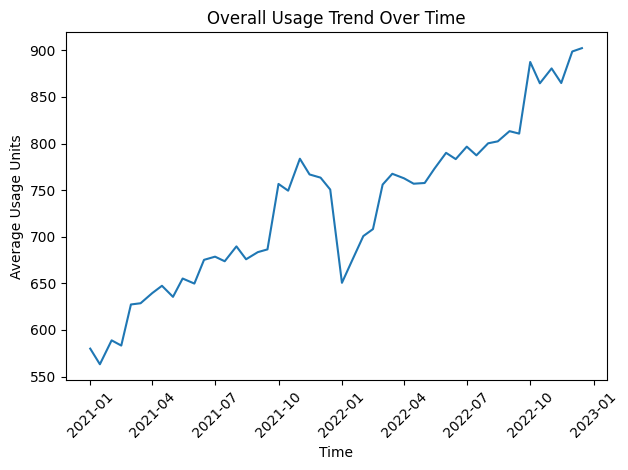

In [27]:
biweekly_trend = df.groupby("time_stamp")["usage_units"].mean()

plt.figure()
plt.plot(biweekly_trend.index, biweekly_trend.values)
plt.xticks(rotation=45)
plt.title("Overall Usage Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Average Usage Units")
plt.tight_layout()
plt.show()


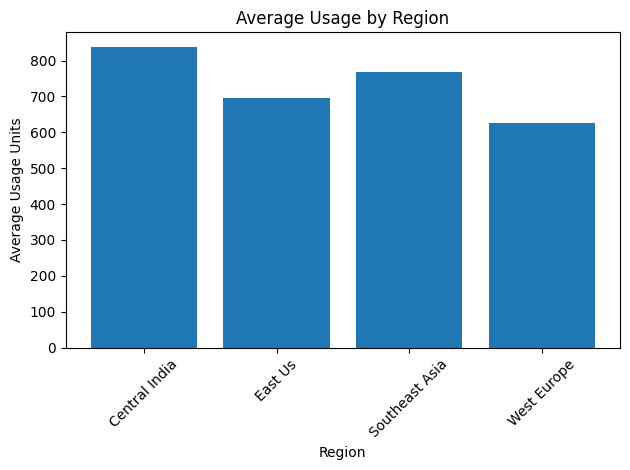

In [28]:
region_trend = df.groupby("region")["usage_units"].mean()

plt.figure()
plt.bar(region_trend.index, region_trend.values)
plt.xticks(rotation=45)
plt.title("Average Usage by Region")
plt.xlabel("Region")
plt.ylabel("Average Usage Units")
plt.tight_layout()
plt.show()


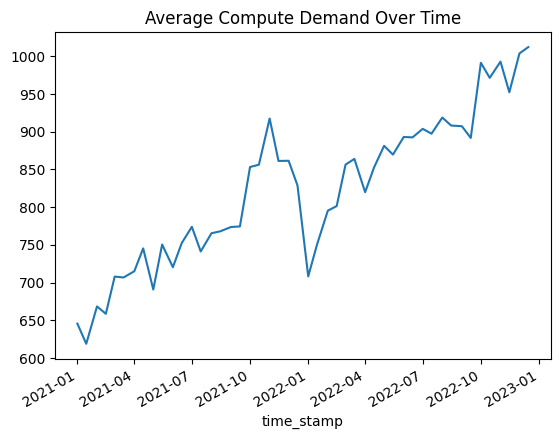

In [29]:
import matplotlib.pyplot as plt

plt.figure()
df[df['service_type']=='Compute'].groupby('time_stamp')['usage_units'].mean().plot()
plt.title("Average Compute Demand Over Time")
plt.show()

In [30]:
df.reset_index(drop=True, inplace=True)

In [31]:
df

,time_stamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact
0,2021-01-01,East Us,Compute,634.35,675.97,76.12,97.64,95.65,90.49,0
1,2021-01-01,East Us,Storage,508.46,577.93,40.68,99.20,95.65,90.49,0
2,2021-01-01,West Europe,Compute,549.87,587.36,74.83,98.23,95.65,90.49,0
3,2021-01-01,West Europe,Storage,441.05,486.25,35.28,98.20,95.65,90.49,0
4,2021-01-01,Central India,Compute,725.42,782.89,87.05,98.59,95.65,90.49,0
...,...,...,...,...,...,...,...,...,...,...
374,2022-12-15,East Us,Storage,776.23,875.98,62.10,99.79,104.38,103.69,0
375,2022-12-15,West Europe,Compute,854.76,956.32,102.57,98.11,104.38,103.69,0
376,2022-12-15,West Europe,Storage,688.60,780.93,55.09,99.66,104.38,103.69,0
377,2022-12-15,Central India,Compute,1200.67,1339.87,144.08,99.03,104.38,103.69,0
